# Clustering analysis

In [74]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from anomaly.utils import get_sdss_spec_img
from anomaly.constants import SDSS_NEBULAR_LINES_RATIOS_NAMES
from astroExplain.spectra.astronomy import BPT
from astroExplain.spectra import clustering
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data igestion

In [2]:
def load_xai(run_id: str, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_arr = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")
    weights = np.load(f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r")
    return anomalies_arr, specobjids_arr, weights

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "unique_norm_weights": None,
        "norm_unique_norm_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["unique_norm_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["norm_weights"], n_segments=n_segments
    )

    data_dict["norm_unique_norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_norm_weights"]
    )

    return data_dict

## Top ranked explanations

In [4]:
def plot_top_ranked_explanations(
    metadata_df,
    spectra,
    norm_weights,
    wave,
    kmeans_model_dir,
    cluster_id,
    download_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
    skip_ranks_list=[-1],
):

    lw = 0.75

    n_anomalies_in_cluster = metadata_df.shape[0]
    print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

    for anomaly_rank in range(0, n_anomalies_in_cluster):

        if anomaly_rank == n_top_ranked:
            break
        if anomaly_rank + 1 in skip_ranks_list:
            print(f"Skipping rank {anomaly_rank + 1}.", end="\n")
            continue

        print(f"Explanation for anomaly rank {anomaly_rank + 1}", end="\r")

        specobjid = metadata_df.index[anomaly_rank]

        if download_images is True:
            os.makedirs(f"{kmeans_model_dir}/cluster_{cluster_id}", exist_ok=True)

            # check if the image already exists
            image_path = (
                f"{kmeans_model_dir}/cluster_{cluster_id}/image_{specobjid}.jpeg"
            )

            if not os.path.exists(image_path):

                ra, dec = metadata_df[["ra", "dec"]].loc[specobjid].values

                get_sdss_spec_img(
                    specobjid,
                    ra,
                    dec,
                    save_to=f"{kmeans_model_dir}/cluster_{cluster_id}",
                )

        spec = spectra[anomaly_rank]

        norm_weights_spec = norm_weights[anomaly_rank]
        if max_norm_weights is True:
            norm_weights_spec /= np.max(norm_weights_spec)

        fig, axs = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(20, 7),
            sharex=True,
            sharey=False,
        )
        # set minor ticks on
        for ax in axs.flatten():
            ax.minorticks_on()
        axs[0].plot(wave, spec, color="black", linewidth=lw)
        # weights
        axs[1].plot(
            wave, norm_weights_spec, color="black",
            label=f"Cluster {cluster_id}", linewidth=lw
        )

        axs[1].set_xlabel(r"$\lambda$ [nm]")
        axs[0].set_ylabel("Normalized flux")
        axs[1].set_ylabel("Explanation weights")
        axs[0].set_title(
            f"Rank: {anomaly_rank + 1:02d} - Cluster: {cluster_id}\n"
            f"Specobjid: {specobjid}"
        )

        axs[1].set_ylim(0, 0.4)
        y_ticks = np.arange(0, 0.41, 0.1)
        axs[1].set_yticks(y_ticks)

        if download_images is True:
            image_name = f"image_{specobjid}.jpeg"
        # Load the image
            img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")

            # Create inset in top-right corner of axs[0]
            width_height_image = 1
            axins = inset_axes(
                axs[0],
                width=width_height_image,
                height=width_height_image,
                bbox_to_anchor=(1.01, 1.02),
                bbox_transform=axs[0].transAxes,
                loc="upper right",
            )

            # Show image in the inset
            axins.imshow(img)
            axins.axis("off")  # Hide axis around the image
        explanation_name = f"rank_{anomaly_rank + 1:02d}_explanation_{specobjid}"
        if max_norm_weights is True:
            explanation_name += "_max_norm"

        save_pdf_dir = f"{kmeans_model_dir}/cluster_{cluster_id}"
        save_jpeg_dir = f"{save_pdf_dir}/explanations_sdss_spec_jpeg"
        # create directories if they don't exist
        os.makedirs(save_pdf_dir, exist_ok=True)
        os.makedirs(save_jpeg_dir, exist_ok=True)
        fig.savefig(f"{save_pdf_dir}/{explanation_name}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_jpeg_dir}/{explanation_name}.jpeg", bbox_inches="tight")
        plt.clf()
        plt.close(fig)

## Explanations

In [5]:
run_ids_343_50k_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607150029_uniform_343_samples_50000_scale_0.9',
    'iforest': 'xai_202607142229_uniform_343_samples_50000_scale_0.9'
}

In [6]:
run_ids_343_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607200003_uniform_343_samples_100000_scale_0.9',
    'iforest': 'xai_202607201307_uniform_343_samples_100000_scale_0.9'
}

# Config

## Directories

In [7]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"
ch_6_dir = f"{thesis_dir}/chapters/06_figures"

## Constants

In [8]:
score_name = "mse"
bin_id = "bin_03"
n_segments = 343
n_clusters = 6

kmeans_model_dir = f"{clustering_dir}/{bin_id}/{score_name}"
kmeans_model_name = f"kmeans_{n_clusters}_clusters_{n_segments}_segments"

if not os.path.exists(kmeans_model_dir):
    os.makedirs(kmeans_model_dir)
print(f"Model ID: {kmeans_model_name}")

Model ID: kmeans_6_clusters_343_segments


## Data

In [9]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

## Explanations

In [10]:
n_samples = 100_000

if n_samples == 100_000:
    run_ids_dict = run_ids_343_dict
elif n_samples == 50_000:
    run_ids_dict = run_ids_343_50k_dict

run_id = run_ids_dict[score_name]

load_from = f"{explanations_dir}/{bin_id}/{score_name}"

print(f"Loading XAI data from: {load_from}")

(
    anomalies_arr,
    specobjids_arr,
    weights_arr,
) = load_xai(run_id=run_id, load_from=load_from)


Loading XAI data from: /home/elom/phd/code/explanations/bin_03/mse


## Order explanations according to score

In [11]:
scores_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    usecols=["specobjid", score_name],
    index_col="specobjid",
).loc[specobjids_arr]

sorted_specobjids_arr = scores_df[score_name].sort_values(
    ascending=False
).index.to_numpy()

# 1. Find the index mapping from specobjids_arr to sorted_specobjids_arr
indexer = pd.Index(specobjids_arr).get_indexer(sorted_specobjids_arr)

# 2. Reorder all three arrays simultaneously using the indexer
specobjids_arr = specobjids_arr[indexer]
anomalies_arr = anomalies_arr[indexer]
weights_arr = weights_arr[indexer]

weights_dict = weights_prep(
    weights=weights_arr, n_segments=n_segments
)

scores_df.loc[specobjids_arr].head(5)

,mse
specobjid,
407596690535639040,51.269002
1413149843194406912,46.845534
378399434137954304,45.943604
1767703038748813312,45.294575
2930814289679771648,44.142569


# K-means model
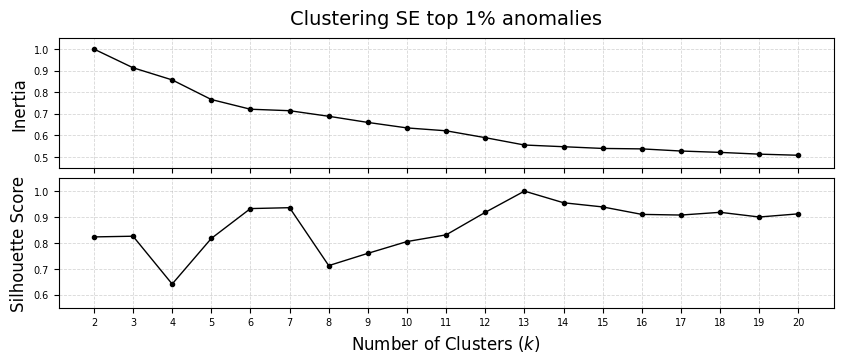

## Train data

In [12]:
X = weights_dict["norm_unique_norm_weights"]

## Train and save

In [13]:
# ```python
start_time = time.perf_counter()

kmeans_model = KMeans(n_clusters=n_clusters, random_state=0).fit(X)
end_time = time.perf_counter()
print(f"train time: {end_time - start_time:.2f} seconds")

# save model
joblib.dump(kmeans_model, f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
# ```

# ```python
# # train time: 0.17 seconds
# # ['/home/elom/phd/code/clustering/bin_03/mse//kmeans_6_clusters_343_segments.joblib']
# ```

train time: 0.18 seconds


['/home/elom/phd/code/clustering/bin_03/mse/kmeans_6_clusters_343_segments.joblib']

## Save metadata

In [14]:
# ```python
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
cluster_labels = kmeans_model.predict(X)

cluster_meta_df = meta_with_ratios_df.loc[specobjids_arr].copy()
cluster_meta_df["cluster"] = cluster_labels

# append score, specobjids_arr is already sorted by score
cluster_meta_df[score_name] = scores_df[score_name].loc[specobjids_arr].copy()
cluster_meta_df.to_csv(f"{kmeans_model_dir}/metadata.csv.gz", compression="gzip")
# ```

# Clusters metadata

In [15]:
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
cluster_labels = kmeans_model.predict(X)

# get spectra and weights per cluster
spectra_cluster_dict, weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=weights_dict["norm_weights"],
    print_n_clusters=True,
)

weights_dict["spectra_cluster_dict"] = spectra_cluster_dict
weights_dict["weights_cluster_dict"] = weights_cluster_dict


weights_dict["centroids"] = kmeans_model.cluster_centers_
# 0;408
# 1;540
# 2;288
# 3;268
# 4;304
# 5;11

0;408
1;540
2;288
3;268
4;304
5;11


In [16]:
cluster_meta_df = pd.read_csv(
    f"{kmeans_model_dir}/metadata.csv.gz", index_col="specobjid"
).loc[specobjids_arr]


# Line ratios

## Median line ratios

In [17]:
median_cluster_ratios_df = pd.DataFrame(
    index=range(0, n_clusters),
    columns=SDSS_NEBULAR_LINES_RATIOS_NAMES,
)
for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id

    median_cluster_ratios_df.loc[cluster_id, "balmer_decrement"] = np.nanmedian(
        cluster_meta_df.loc[mask, "balmer_decrement"]
    )
    median_cluster_ratios_df.loc[cluster_id, "nii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "nii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_hbeta"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_hbeta"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_oii"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_oii"]
    )
    median_cluster_ratios_df.loc[cluster_id, "o3n2_index"] = np.nanmedian(
        cluster_meta_df.loc[mask, "o3n2_index"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_density_ratio"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_density_ratio"]
    )
# map col name by replacing the '_' with ' ' for better readability
median_cluster_ratios_df.columns = [
    col.replace("_", " ") for col in median_cluster_ratios_df.columns
]

median_cluster_ratios_df.to_clipboard(excel=True, index=True)
median_cluster_ratios_df

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
0,3.748319,0.409706,1.387313,1.236246,0.330914,1.359598,0.582592
1,3.795329,0.248739,1.38852,1.272412,0.249302,1.347979,0.721755
2,4.158723,0.478891,1.135001,1.315719,0.299656,1.257105,0.438656
3,3.476272,0.124339,3.69105,3.908726,0.225046,1.345153,1.335211
4,3.3487,0.151872,1.846447,1.334979,0.263048,1.389719,1.080119
5,3.580772,0.831059,1.614317,0.611927,0.422282,1.385509,0.223745


## Cluster 0 ratios percentiles

In [18]:
cluster_mask = cluster_meta_df["cluster"] == 0
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,50th,55th
balmer decrement,3.621760,3.748319,3.851186
nii to halpha,0.370434,0.409706,0.471654
oiii to hbeta,1.169369,1.387313,1.668439
oiii to oii,1.070667,1.236246,1.373117
sii to halpha,0.315909,0.330914,0.344922
sii density ratio,1.343743,1.359598,1.378721
o3n2 index,0.504025,0.582592,0.665055


## Cluster 1 ratios percentiles

In [19]:
cluster_mask = cluster_meta_df["cluster"] == 1
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,50th,55th
balmer decrement,3.701747,3.795329,3.854598
nii to halpha,0.227310,0.248739,0.267406
oiii to hbeta,1.279288,1.388520,1.544875
oiii to oii,1.174278,1.272412,1.380417
sii to halpha,0.240099,0.249302,0.257709
sii density ratio,1.336275,1.347979,1.356433
o3n2 index,0.642140,0.721755,0.794518


## Cluster 2 percentiles

In [20]:
cluster_mask = cluster_meta_df["cluster"] == 2
percentiles = np.arange(0.45, 0.6, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,50th,55th
balmer decrement,4.065209,4.158723,4.251897
nii to halpha,0.433916,0.478891,0.514431
oiii to hbeta,1.005109,1.135001,1.326386
oiii to oii,1.099021,1.315719,1.539738
sii to halpha,0.285458,0.299656,0.313069
sii density ratio,1.241386,1.257105,1.270817
o3n2 index,0.373414,0.438656,0.502382


## Cluster 3 ratios percentiles

In [21]:
cluster_mask = cluster_meta_df["cluster"] == 3
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,50th,55th
balmer decrement,3.410375,3.476272,3.528410
nii to halpha,0.114530,0.124339,0.158644
oiii to hbeta,3.487660,3.691050,3.900455
oiii to oii,3.456300,3.908726,4.189765
sii to halpha,0.212969,0.225046,0.243115
sii density ratio,1.329832,1.345153,1.358399
o3n2 index,1.280099,1.335211,1.419166


## Cluster 4 ratios percentiles

In [22]:
cluster_mask = cluster_meta_df["cluster"] == 4
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,50th,55th
balmer decrement,3.315752,3.348700,3.388143
nii to halpha,0.140892,0.151872,0.163607
oiii to hbeta,1.736266,1.846447,2.005748
oiii to oii,1.252688,1.334979,1.462596
sii to halpha,0.251553,0.263048,0.271062
sii density ratio,1.380456,1.389719,1.398574
o3n2 index,1.027377,1.080119,1.156284


## Cluster 5 percentiles

In [23]:
cluster_mask = cluster_meta_df["cluster"] == 5
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,50th,55th
balmer decrement,3.503744,3.580772,3.657800
nii to halpha,0.709114,0.831059,0.953005
oiii to hbeta,1.611027,1.614317,1.617606
oiii to oii,0.580050,0.611927,0.643804
sii to halpha,0.375494,0.422282,0.490109
sii density ratio,1.149640,1.385509,1.399878
o3n2 index,0.191071,0.223745,0.276873


# Redshift Analysis

In [24]:
z_dict = {"cluster": [], "z_min": [], "z_max": [], "z_mean": [], "z_median": []}

for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id
    z = cluster_meta_df["z"].loc[mask].values

    z_dict["cluster"].append(cluster_id)
    z_dict["z_min"].append(np.min(z))
    z_dict["z_max"].append(np.max(z))
    z_dict["z_mean"].append(np.mean(z))
    z_dict["z_median"].append(np.median(z))
z_df = pd.DataFrame(z_dict)
z_df

,cluster,z_min,z_max,z_mean,z_median
0,0,0.010673,0.262315,0.090362,0.089639
1,1,0.010093,0.261698,0.068517,0.055840
2,2,0.011134,0.271920,0.083456,0.075833
3,3,0.010262,0.234167,0.053717,0.035546
4,4,0.011578,0.179591,0.042405,0.027792
5,5,0.067039,0.089808,0.085675,0.088545


In [25]:
low_wave, upper_wave = 5_565, 5_590
z_df["lower_wave_min"] = low_wave / (1 + z_df["z_min"])
z_df["upper_wave_min"] = upper_wave / (1 + z_df["z_min"])
z_df["lower_wave_max"] = low_wave / (1 + z_df["z_max"])
z_df["upper_wave_max"] = upper_wave / (1 + z_df["z_max"])
z_df["lower_wave_mean"] = low_wave / (1 + z_df["z_mean"])
z_df["upper_wave_mean"] = upper_wave / (1 + z_df["z_mean"])
z_df["lower_wave_median"] = low_wave / (1 + z_df["z_median"])
z_df["upper_wave_median"] = upper_wave / (1 + z_df["z_median"])
z_df

,cluster,z_min,z_max,z_mean,z_median,lower_wave_min,upper_wave_min,lower_wave_max,upper_wave_max,lower_wave_mean,upper_wave_mean,lower_wave_median,upper_wave_median
0,0,0.010673,0.262315,0.090362,0.089639,5506.234165,5530.970168,4408.565054,4428.369928,5103.811464,5126.739637,5107.195584,5130.138961
1,1,0.010093,0.261698,0.068517,0.055840,5509.396417,5534.146625,4410.724441,4430.539016,5208.151117,5231.548022,5270.685177,5294.363008
2,2,0.011134,0.271920,0.083456,0.075833,5503.724177,5528.448904,4375.274831,4394.930153,5136.339973,5159.414277,5172.738105,5195.975922
3,3,0.010262,0.234167,0.053717,0.035546,5508.474568,5533.220635,4509.113149,4529.369722,5281.304631,5305.030168,5373.975926,5398.117777
4,4,0.011578,0.179591,0.042405,0.027792,5501.307240,5526.021109,4717.738510,4738.932304,5338.615019,5362.598016,5414.518142,5438.842122
5,5,0.067039,0.089808,0.085675,0.088545,5215.368428,5238.797756,5106.404064,5129.343884,5125.845717,5148.872877,5112.326917,5135.293345


# Clusters' XAI

## Centroid & Avg Spec

In [26]:
lw = 0.75
for label, centroid in enumerate(weights_dict["centroids"]):

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    centroid = clustering.expand_weights_per_segments(
        centroid.reshape(1, -1),
        wave_nm.size,
        n_segments,
    )
    centroid = clustering.normalize_weights_l2_abs(centroid).reshape(-1)
    avg_spectrum = weights_dict["spectra_cluster_dict"][label].mean(axis=0)

    axs[0].plot(
        wave_nm, avg_spectrum, color="black", label="Average spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, centroid, color="black", label="Centroid explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    # set limits
    axs[1].set_ylim(0, 0.31)
    y_ticks = np.arange(0, 0.31, 0.1)
    axs[1].set_yticks(y_ticks)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label}",
        fontsize=12,
    )

    plot_name = f"avg_spec_centroid_{label}"

    save_to = f"{kmeans_model_dir}/avg_spec_centroids"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Centroid & Median Spec

In [27]:
lw = 0.75
for label, centroid in enumerate(weights_dict["centroids"]):

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    centroid = clustering.expand_weights_per_segments(
        centroid.reshape(1, -1),
        wave_nm.size,
        n_segments,
    )
    centroid = clustering.normalize_weights_l2_abs(centroid).reshape(-1)
    _spec = weights_dict["spectra_cluster_dict"][label]
    med_spec = np.nanmedian(_spec, axis=0)

    axs[0].plot(
        wave_nm, med_spec, color="black", label="Median spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, centroid, color="black", label="Centroid explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    # set limits
    axs[1].set_ylim(0, 0.31)
    y_ticks = np.arange(0, 0.31, 0.1)
    axs[1].set_yticks(y_ticks)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label}",
        fontsize=12,
    )

    plot_name = f"median_spec_centroid_{label}"

    save_to = f"{kmeans_model_dir}/median_spec_centroids"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Avg Spec & XAI

In [28]:
lw = 0.75
for label_cluster, weights in weights_dict['weights_cluster_dict'].items():

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    spec = weights_dict["spectra_cluster_dict"][label_cluster]

    avg_spectrum = spec.mean(axis=0)
    avg_weights = weights.mean(axis=0)

    axs[0].plot(
        wave_nm, avg_spectrum, color="black", label="Average spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, avg_weights, color="black", label="Average explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 0.31)
    y_ticks = np.arange(0, 0.31, 0.1)
    axs[1].set_yticks(y_ticks)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label_cluster}",
        fontsize=12,
    )

    plot_name = f"avg_spec_xai_{label_cluster}"

    save_to = f"{kmeans_model_dir}/avg_spec_xai"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Median Spec & XAI

In [29]:
lw = 0.75
for label_cluster, weights in weights_dict['weights_cluster_dict'].items():

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    spec = weights_dict["spectra_cluster_dict"][label_cluster]

    median_spec = np.nanmedian(spec, axis=0)
    median_weights = np.nanmedian(weights, axis=0)

    axs[0].plot(
        wave_nm, median_spec, color="black", label="Median spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, median_weights, color="black", label="Median explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 0.31)
    y_ticks = np.arange(0, 0.31, 0.1)
    axs[1].set_yticks(y_ticks)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label_cluster}",
        fontsize=12,
    )

    plot_name = f"median_spec_xai_{label_cluster}"

    save_to = f"{kmeans_model_dir}/median_spec_xai"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

# Top ranked anomalies per cluster

In [30]:
# cluster_id = 0

# mask = cluster_meta_df["cluster"] == cluster_id

# metadata_df = cluster_meta_df.loc[mask].sort_values(
#     by=f"{score_name}", ascending=False
# )

# spectra = anomalies_arr[mask]
# norm_weights = weights_dict["norm_weights"][mask]

# plot_top_ranked_explanations(
#     cluster_id=cluster_id,
#     metadata_df=metadata_df,
#     spectra=spectra,
#     norm_weights=norm_weights,
#     wave=wave_nm,
#     kmeans_model_dir=kmeans_model_dir,
#     download_images=True,
#     n_top_ranked=-1,
#     max_norm_weights=False,
#     # skip_ranks_list=[132] # for cluster 0
#     # skip_ranks_list=[79] # for cluster 2
# )

In [31]:
cluster_id = 2
mask = cluster_meta_df["cluster"] == cluster_id
metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)
spec_id = metadata_df.index[78]
meta.get_sky_server_url(spec_id)

'http://skyserver.sdss.org/dr16/en/tools/explore/summary.aspx?sid=2823895569838139392&apid='

## Check ranking

In [32]:
cluster_id = 0
mask = cluster_meta_df["cluster"] == cluster_id
metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)

spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]
metadata_df.loc[:, ["cluster", score_name]].head(10)
# scores_df.loc[mask].head(10)


,cluster,mse
specobjid,,
407596690535639040,0,51.269002
1413149843194406912,0,46.845534
378399434137954304,0,45.943604
1767703038748813312,0,45.294575
1610143844655982592,0,42.411082
407595591024011264,0,38.202324
305239577747023872,0,38.080637
407586794930989056,0,34.455075
2836210386607302656,0,33.200128


In [33]:
anomaly_rank = 0
cluster_id = 1

mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)

n_anomalies_in_cluster = metadata_df.shape[0]
print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

specobjid = metadata_df.index[anomaly_rank]
metadata_df.loc[specobjid, ["cluster", score_name]]

Number of anomalies in cluster 1: 540


cluster            1
mse        44.142569
Name: 2930814289679771648, dtype: object

In [34]:
# mask of oiii_to_oii = nan
cluster_id = 4
mask_cluster = cluster_meta_df["cluster"] == cluster_id
mask_oiii_to_oii_nan = cluster_meta_df.loc[mask_cluster]["oiii_to_oii"].isna()
n_nan = mask_oiii_to_oii_nan.sum()
n_total = mask_oiii_to_oii_nan.shape[0]
pct_valid = (n_total - n_nan) / n_total * 100
pct_nan = n_nan / n_total * 100
print(f"Cluster {cluster_id}: {n_nan} out of {n_total} have NaN oiii_to_oii values.\n")
print(f"\t{pct_nan:.0f}% have NaN oiii_to_oii values.")
print(f"\t{pct_valid:.0f}% have valid oiii_to_oii values.")
# specobjid = 3320337450726877184
# cluster_meta_df.loc[
#     specobjid,
#     [
#         'oii_3726_flux', 'oii_3729_flux', 'oiii_4959_flux', 'oiii_5007_flux',
#         'oiii_flux', 'oiii_to_oii'
#     ] + ['z', "cluster", score_name]
# ]

Cluster 4: 103 out of 304 have NaN oiii_to_oii values.

	34% have NaN oiii_to_oii values.
	66% have valid oiii_to_oii values.


# BPT

['(0)', '(1)', '(2)', '(3)', '(4)', '(5)']
[-0.38752737 -0.60425643 -0.31976309 -0.90539198 -0.81852188 -0.0803679 ]
[0.14217459 0.1425521  0.05499638 0.56714998 0.26633696 0.20798873]


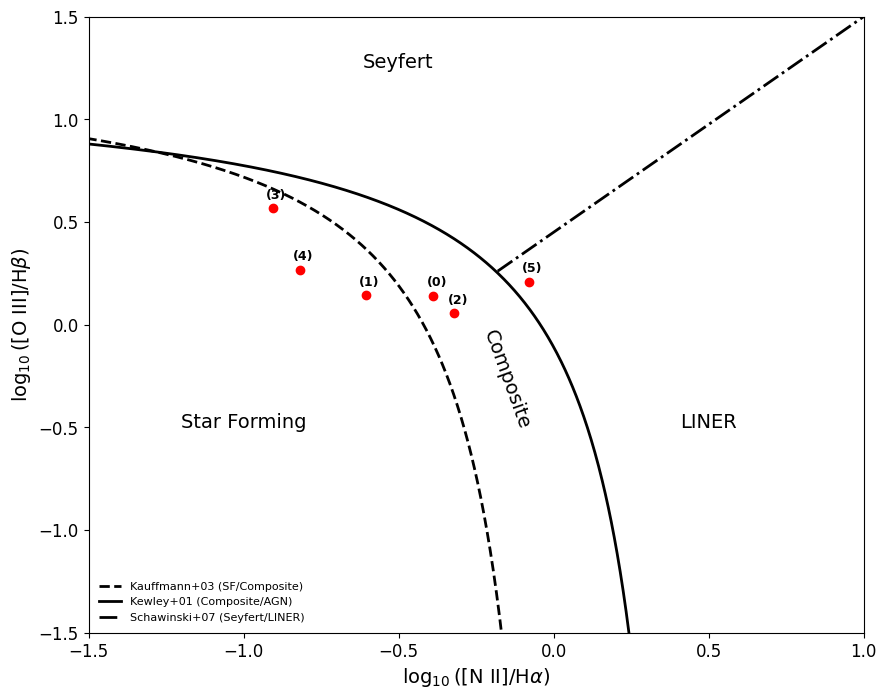

In [75]:
labels = [f"({i})" for i in range(0, n_clusters)]
print(labels)

n2_ha = median_cluster_ratios_df["nii to halpha"].to_list()
o3_hb = median_cluster_ratios_df["oiii to hbeta"].to_list()
log_n2_ha = np.log10(n2_ha)
log_o3_hb = np.log10(o3_hb)

print(log_n2_ha)
print(log_o3_hb)

fig, ax = plt.subplots(figsize=(10, 8))
fig, ax = BPT.standar_bpt_plot(fig, ax, log_n2_ha, log_o3_hb, labels, xytext=(-5, 5))

# Cluster 0 & 5

## Data prep

In [46]:
# Cluster 0
weights_0 = weights_dict["weights_cluster_dict"][0]
med_weights_0 = np.nanmedian(weights_0, axis=0)
spec_0 = weights_dict["spectra_cluster_dict"][0]
med_spec_0 = np.nanmedian(spec_0, axis=0)

# Cluster 5
weights_5 = weights_dict["weights_cluster_dict"][5]
med_weights_5 = np.nanmedian(weights_5, axis=0)
spec_5 = weights_dict["spectra_cluster_dict"][5]
med_spec_5 = np.nanmedian(spec_5, axis=0)

## Figure

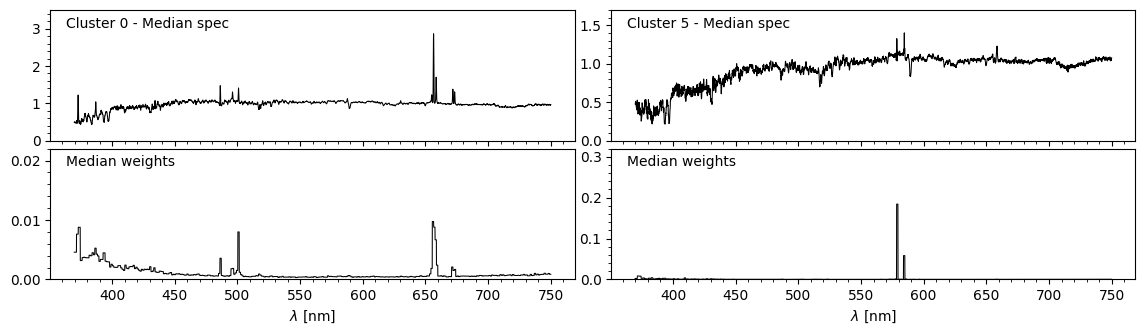

In [58]:
lw = 0.75

fig, axs = plt.subplots(
    nrows=2, ncols=2,
    figsize=(14, 3.5),
    sharex=True,
    sharey=False,
)

# Cluster 0
axs[0, 0].plot(wave_nm, med_spec_0, color="black", linewidth=lw)

y_lims = (0, 3.5)
y_ticks = range(0, 4, 1)
axs[0, 0].set_ylim(y_lims)
axs[0, 0].set_yticks(y_ticks)

# weights
axs[1, 0].plot(wave_nm, med_weights_0, color="black", linewidth=lw)

# ------------------------------------------------------------------
# Cluster 5
axs[0, 1].plot(wave_nm, med_spec_5, color="black", linewidth=lw)
y_lims = (0, 1.7)
y_ticks = np.arange(0, 1.7, 0.5)
axs[0, 1].set_ylim(y_lims)
axs[0, 1].set_yticks(y_ticks)


# weights
axs[1, 1].plot(wave_nm, med_weights_5, color="black", linewidth=lw)
# --------------------------------------------------------------------
y_lims = (0, 0.022)
y_ticks = np.arange(0, 0.025, 0.01)
axs[1, 0].set_ylim(y_lims)
axs[1, 0].set_yticks(y_ticks)

y_lims = (0, 0.32)
y_ticks = np.arange(0, 0.32, 0.1)
axs[1, 1].set_ylim(y_lims)
axs[1, 1].set_yticks(y_ticks)
# wavelength
axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")

# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# add text cluster 0
axs[0, 0].text(
    0.03, 0.95, 'Cluster 0 - Median spec', transform=axs[0, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

axs[1, 0].text(
    0.03, 0.95, 'Median weights', transform=axs[1, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

# add text cluster 5
axs[0, 1].text(
    0.03, 0.95, 'Cluster 5 - Median spec', transform=axs[0, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)
axs[1, 1].text(
    0.03, 0.95, 'Median weights', transform=axs[1, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

plt.subplots_adjust(hspace=0.06, wspace=0.07)
plt.show()
# # save fig
fname = 'se_cluster_0_5'
fig.savefig(f"{ch_6_dir}/{fname}_med.pdf", bbox_inches="tight")

## SDSS class

In [37]:
cluster_id = 0
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)

subClass
NaN              135
STARFORMING      110
STARBURST         81
AGN               55
AGN BROADLINE     17
BROADLINE         10
Name: count, dtype: int64

In [38]:
cluster_id = 5
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)

subClass
NaN            7
STARFORMING    2
STARBURST      1
BROADLINE      1
Name: count, dtype: int64

# Clusters 1-4

## Data prep

In [39]:
# Cluster 1
weights_1 = weights_dict["weights_cluster_dict"][1]
med_weights_1 = np.nanmedian(weights_1, axis=0)
spec_1 = weights_dict["spectra_cluster_dict"][1]
med_spec_1 = np.nanmedian(spec_1, axis=0)

# Cluster 2
weights_2 = weights_dict["weights_cluster_dict"][2]
med_weights_2 = np.nanmedian(weights_2, axis=0)
spec_2 = weights_dict["spectra_cluster_dict"][2]
med_spec_2 = np.nanmedian(spec_2, axis=0)

# Cluster 3
weights_3 = weights_dict["weights_cluster_dict"][3]
med_weights_3 = np.nanmedian(weights_3, axis=0)
spec_3 = weights_dict["spectra_cluster_dict"][3]
med_spec_3 = np.nanmedian(spec_3, axis=0)

# Cluster 4
weights_4 = weights_dict["weights_cluster_dict"][4]
med_weights_4 = np.nanmedian(weights_4, axis=0)
spec_4 = weights_dict["spectra_cluster_dict"][4]
med_spec_4 = np.nanmedian(spec_4, axis=0)

## Figure

1
3


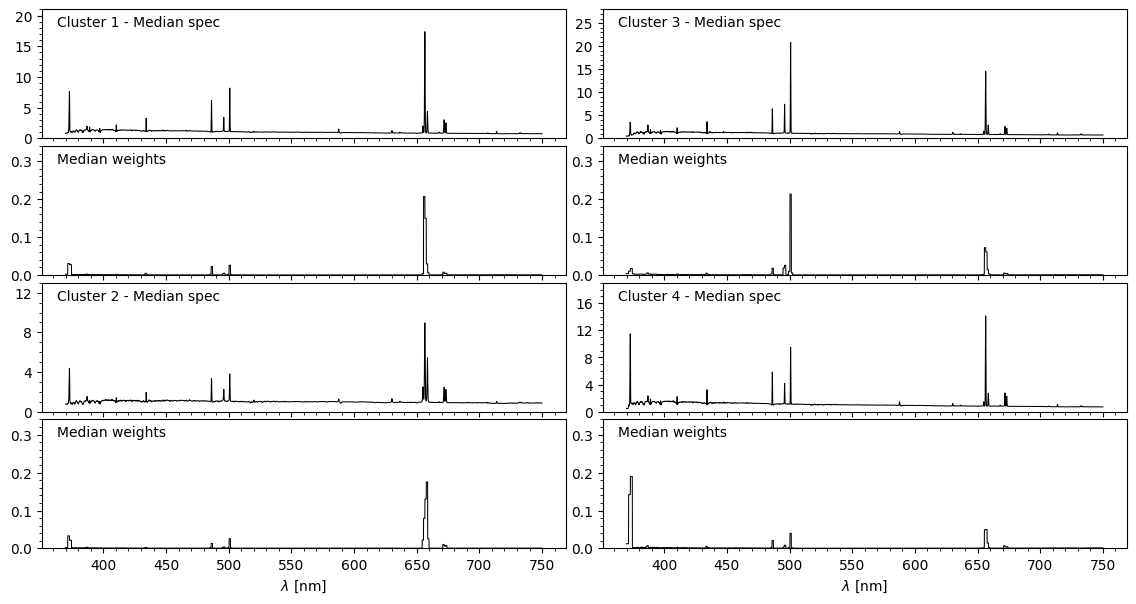

In [72]:
lw = 0.75

fig, axs = plt.subplots(
    nrows=4, ncols=2,
    figsize=(14, 7),
    sharex=True,
    sharey=False,
)

# ------------------------------------------------------------------
# Cluster 1
axs[0, 0].plot(wave_nm, med_spec_1, color="black", linewidth=lw)

y_lims = (0, 21)
y_ticks = np.arange(0, 21, 5)
axs[0, 0].set_ylim(y_lims)
axs[0, 0].set_yticks(y_ticks)

# weights
axs[1, 0].plot(wave_nm, med_weights_1, color="black", linewidth=lw)

# ------------------------------------------------------------------
# Cluster 2
axs[2, 0].plot(wave_nm, med_spec_2, color="black", linewidth=lw)

y_lims = (0, 13)
y_ticks = np.arange(0, 13, 4)
axs[2, 0].set_ylim(y_lims)
axs[2, 0].set_yticks(y_ticks)

# weights
axs[3, 0].plot(wave_nm, med_weights_2, color="black", linewidth=lw)

# ------------------------------------------------------------------
# Cluster 3
axs[0, 1].plot(wave_nm, med_spec_3, color="black", linewidth=lw)

y_lims = (0, 28)
y_ticks = np.arange(0, 28, 5)
axs[0, 1].set_ylim(y_lims)
axs[0, 1].set_yticks(y_ticks)

# weights
axs[1, 1].plot(wave_nm, med_weights_3, color="black", linewidth=lw)

# ------------------------------------------------------------------
# Cluster 4
axs[2, 1].plot(wave_nm, med_spec_4, color="black", linewidth=lw)

y_lims = (0, 19)
y_ticks = np.arange(0, 18, 4)
axs[2, 1].set_ylim(y_lims)
axs[2, 1].set_yticks(y_ticks)

# weights
axs[3, 1].plot(wave_nm, med_weights_4, color="black", linewidth=lw)

# --------------------------------------------------------------------
# lim and ticks for explanation weights
y_lims = (0, 0.34)
y_ticks = np.arange(0, 0.34, 0.1)

for i in range(0, 4, 2):
    print(i + 1)
    axs[i + 1, 0].set_ylim(y_lims)
    axs[i + 1, 0].set_yticks(y_ticks)
    axs[i + 1, 1].set_ylim(y_lims)
    axs[i + 1, 1].set_yticks(y_ticks)

# wavelength
axs[-1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[-1, 1].set_xlabel(r"$\lambda$ [nm]")

# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# add text
for i in range(0, 2):

    axs[i * 2, 0].text(
        0.03, 0.95, f'Cluster {i + 1} - Median spec',
        transform=axs[i * 2, 0].transAxes,
        # fontsize=14,
        verticalalignment='top',
    )
    axs[i * 2 + 1, 0].text(
        0.03, 0.95, 'Median weights',
        # 0.03, 0.95, f'Cluster {i + 1} - Median weights',
        transform=axs[i * 2 + 1, 0].transAxes,
        # fontsize=14,
        verticalalignment='top',
    )

    axs[i * 2, 1].text(
        0.03, 0.95, f'Cluster {i + 3} - Median spec',
        transform=axs[i * 2, 1].transAxes,
        # fontsize=14,
        verticalalignment='top',
    )
    axs[i * 2 + 1, 1].text(
        0.03, 0.95, 'Median weights',
        # 0.03, 0.95, f'Cluster {i + 3} - Median weights',
        transform=axs[i * 2 + 1, 1].transAxes,
        # fontsize=14,
        verticalalignment='top',
    )

plt.subplots_adjust(hspace=0.06, wspace=0.07)
plt.show()
# save fig
fname = 'se_cluster_1_to_4'
fig.savefig(f"{ch_6_dir}/{fname}_med.pdf", bbox_inches="tight")

## SDSS class

In [42]:
cluster_id = 1
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
STARBURST                89.814815
STARFORMING               4.074074
AGN                       2.407407
NaN                       2.222222
STARBURST BROADLINE       1.111111
STARFORMING BROADLINE     0.370370
Name: count, dtype: float64

In [43]:
cluster_id = 2
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
STARBURST                57.638889
AGN                      20.138889
STARFORMING              10.069444
NaN                       4.861111
AGN BROADLINE             3.819444
BROADLINE                 1.388889
STARBURST BROADLINE       1.041667
STARFORMING BROADLINE     1.041667
Name: count, dtype: float64

In [44]:
cluster_id = 3
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
STARBURST        63.805970
AGN              26.119403
STARFORMING       4.850746
AGN BROADLINE     4.104478
NaN               1.119403
Name: count, dtype: float64

In [45]:
cluster_id = 4
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
STARBURST      78.947368
STARFORMING    17.763158
NaN             2.631579
AGN             0.657895
Name: count, dtype: float64